# mnist-visual-fields

Importing libraries

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os
from typing import Tuple, List, Dict, Callable
from dataset.dataset import Dataset, Data, DataTwoFields
from utils.utils import *
from plotting_network.plotting_network import *
from metrics.metrics import *

2024-09-16 20:04:17.699425: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-16 20:04:17.735681: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-16 20:04:17.735712: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-16 20:04:17.736932: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-16 20:04:17.743368: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-16 20:04:17.743810: I tensorflow/core/platform/cpu_feature_guard.cc:1

TypeError: module() takes at most 2 arguments (3 given)

Libary to get memory consumption

In [2]:
%load_ext memory_profiler

Check if tensorflow is using GPU

In [4]:
if tf.config.list_physical_devices('GPU'):
  print("TensorFlow **IS** using the GPU")
else:
  print("TensorFlow **IS NOT** using the GPU")

TensorFlow **IS NOT** using the GPU


### Importing MNIST dataset and normalizing input

In [4]:
mnist_dataset = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist_dataset.load_data()
x_train, x_test = normalize_dataset(x_train, x_test)

### Generating training dataset

In [5]:
x_train_left, x_train_right, y_train_final = build_double_visual_fields_dataset(
    x_train,
    y_train,
    proportion_cs=0.5,
    proportion_left=0.5,
    full_attention_value=1,
    reduced_attention_value=0.5,
    ss_attention_value=0.5,
)

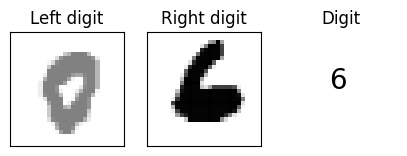

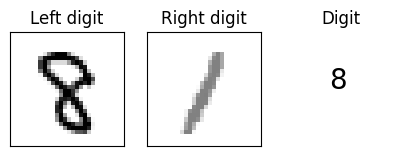

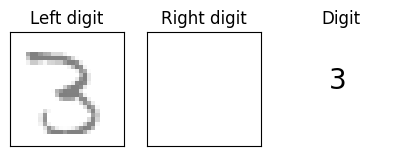

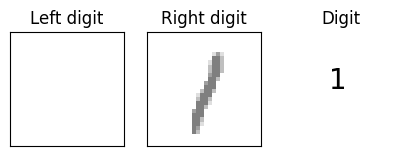

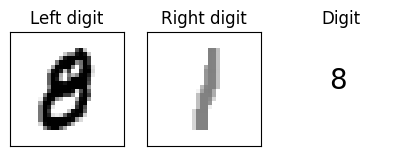

In [6]:
show_dataset(x_train_left, x_train_right, y_data=y_train_final, num_images=5, print_index=False)

### Generating testing dataset

In [7]:
x_test_left, x_test_right, y_test_final = build_double_visual_fields_dataset(
    x_test,
    y_test,
    proportion_cs=0.5,
    proportion_left=0.5,
    full_attention_value=1,
    reduced_attention_value=0.5,
    ss_attention_value=0.5,
)

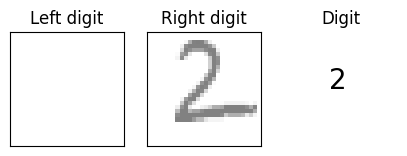

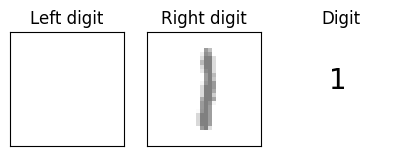

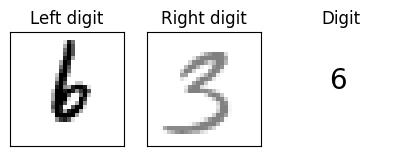

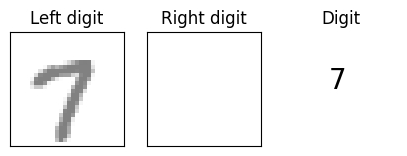

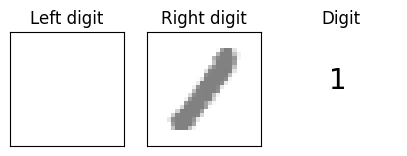

In [8]:
show_dataset(x_test_left, x_test_right, y_data=y_test_final, num_images=5, print_index=False)

Plotting double visual field neural network function

In [15]:
def display_double_visual_field_mnist_nn_execution(
    model: tf.keras.Model,
    left_vf_data: np.array,
    right_vf_data: np.array,
    max_neurons: int = 300,
    weight_plot_threshold: float = 0.5,
    output_models: List[tf.keras.Model] = None,
    k: int = 3,
    save_image: bool = True
):
    """
    Receives a trained model with two visual fields and an input, displaying the entire neural network with its
    activations for that input.

    Observation: the attention value for each visual field is supposed to already be applied to the input data.

    Input:
    model: tf.keras.Model: model to be used for visualization
    left_vf_data: np.array: left visual field data
    right_vf_data: np.array: right visual field data
    max_neurons: int: maximum number of neurons to be plotted in a layer (default: 300)
    weight_plot_threshold: float: minimum weight value to be plotted, considering normalized values between 0 and 1 (default: 0.5)
    output_models: List[tf.keras.Model] | None: list of models to be used as attribute lenses for each layer (default: None)
    k: int: number of top digit activations displayed for each attribute lens (default: 3)
    save_image: bool: if the neural network plot should be saved as an image (default: True)

    Output:
    displays and saves the image in results/images/ if requested
    """

    """ Determining matplotlib figure parameters """

    fig = plt.figure(figsize=(24, 24))
    ax = fig.gca()
    ax.axis("off")
    top, bottom, left, right = compute_figure_sizes(top=0.98)
    middle = round((top + bottom) / 2, ndigits=4)
    middle_spacing = 0.02

    """ Calculating neural network activations """
    
    model_activations = compute_activations(model, left_vf_data, right_vf_data)
        
    """ Determining neural network figure parameters """

    connection_opacity = 0.2
    color_connection_opacity = 0.5
    left_vf_position = Position(left, 1.5 * middle)  # Initial position of left visual field
    right_vf_position = Position(left, 0.5 * middle)  # Initial position of right visual field

    """ Plotting layers """

    model_number_of_layers = len(model.layers)
    plotted_layers_left_vf = []
    plotted_layers_right_vf = []
    plotted_layers_concatenated = []
    layers_reference = None

    # Input layers

    # Left
    input_layer_left = Layer(model=model.layers[2], activations=model_activations[2])
    input_layer_left.position = left_vf_position.copy()
    ab = generate_image_annotation_box(
        get_image(input_layer_left.activations),
        input_layer_left.position,
        cmap="binary",
        size=calculate_image_size(input_layer_left.num_neurons),
    )
    ax.add_artist(ab)
    plotted_layers_left_vf.append(input_layer_left)

    # Right
    input_layer_right = Layer(model=model.layers[3], activations=model_activations[3])
    input_layer_right.position = right_vf_position.copy()
    ab = generate_image_annotation_box(
        get_image(input_layer_right.activations),
        input_layer_right.position,
        cmap="binary",
        size=calculate_image_size(input_layer_right.num_neurons),
    )
    ax.add_artist(ab)
    plotted_layers_right_vf.append(input_layer_right)

    # Plotting the rest of the layers

    # Variables used to keep track of each visual field
    left_idx = 0
    right_idx = 0
    concat_idx = 0
    concat_left_idx = 0
    concat_right_idx = 0
    neuron_digit = 0
    is_concatenated = False
    is_concatenate_layer = False
    is_output_layer = False
    plot_connections_left_vf = True  # Used in concatenate layer

    # Plotting layers, either left vf, right vf or concatenated vf
    for i in range(4, model_number_of_layers):
        model_layer = model.layers[i]
        layer_activations = model_activations[i]
        layer = Layer(model=model_layer, activations=layer_activations)
        # Adjust layer spacing based on current layer
        layer_spacing = 0.05 if i in {4, 5} else  max((1.3) / (model_number_of_layers - 4), 0)

        # Determining if it is plotting left vf, right vf or concatenated vf
        vf_top = top
        vf_bottom = bottom
        if "left" in layer.model.name:
            layers_reference = plotted_layers_left_vf
            left_idx += 1
            layers_idx = left_idx
            vf_bottom = middle + middle_spacing
        elif "right" in layer.model.name:
            layers_reference = plotted_layers_right_vf
            right_idx += 1
            layers_idx = right_idx
            vf_top = middle - middle_spacing
        elif "concatenate" in layer.model.name:
            is_concatenate_layer = True
            is_concatenated = True
            layers_reference = plotted_layers_concatenated
            layers_idx = concat_idx
        elif is_concatenated:
            concat_idx += 1
            layers_idx = concat_idx
        if i == model_number_of_layers - 1:
            is_output_layer = True
            output_offset = 0.2
            vf_top = middle + output_offset
            vf_bottom = middle - output_offset

        # Adds current layer to plotted layers for each visual field
        layers_reference.append(layer)

        # Gets previous layer and layer weights
        if not is_concatenate_layer:
            layer_weights = normalize_ndarray(layer.model.get_weights()[0])  # Retruns 2d-array (num_neurons_previous_layer x num_neurons_current_layer)
                                                                             # get_weights returns (weights, bias)
            previous_layer = layers_reference[layers_idx - 1]
            current_position = previous_layer.position.copy()

        # Determines and saves position of current layer
        current_position.x += layer_spacing
        current_position.y = vf_top
        layer.position = current_position.copy()

        # Determines neuron spacing
        neuron_spacing = (vf_top - vf_bottom) / layer.num_neurons
        # ns_min = 0.05
        # neuron_spacing = min(neuron_spacing, ns_min)

        # Normalize layer activations if it is not output layer
        layer_activations = (
            normalize_ndarray(layer_activations)
            if not is_output_layer
            else layer_activations
        )
        for idx, neuron_activation in enumerate(layer_activations):
            # -- Plotting each neuron --
            neuron = Neuron(
                neuron_activation, current_position.copy(), radius=neuron_spacing / 4
            )
            layer.neurons.append(neuron)  # Adding neuron to plotted layer
            neuron_circle = plt.Circle(
                xy=(current_position.x, current_position.y),
                radius=neuron.radius,
                color=plt.cm.viridis(neuron_activation),
                ec="k",
            )
            ax.add_artist(neuron_circle)  # Plots neuron

            if not is_concatenate_layer:
                # -- Plotting connections of neurons to previous layer --
                if (previous_layer.num_neurons < max_neurons):  # Checks number of neurons on previous layer to decide if every connection will be plotted
                    layer_weights_neuron = layer_weights[:, idx]
                    for previous_neuron, connection_weight in zip(previous_layer.neurons, layer_weights_neuron):
                        # Checks if weight is above threshold
                        if connection_weight >= weight_plot_threshold:
                            connection = plt.Line2D(
                                [
                                    current_position.x - neuron.radius,
                                    previous_neuron.position.x + previous_neuron.radius,
                                ],
                                [current_position.y, previous_neuron.position.y],
                                color=plt.cm.viridis(connection_weight),
                                alpha=color_connection_opacity,
                            )
                            ax.add_artist(connection)  # Plots connection to previous neurons

                else:  # In case it does, only a single connection from each neuron will be shown connecting to the previous layer
                    image_offset = 0.032
                    connection = plt.Line2D(
                        [
                            current_position.x - neuron.radius,
                            previous_layer.position.x + image_offset,
                        ],
                        [current_position.y, previous_layer.position.y],
                        color="k",
                        alpha=connection_opacity,
                    )
                    ax.add_artist(connection)  # Plots connection to image
            # If it is the concatenate layer, show connection to corresponding neuron
            else:
                # Left
                left_vf_layer = plotted_layers_left_vf[left_idx]
                if concat_left_idx < left_vf_layer.num_neurons:
                    previous_neuron = left_vf_layer.neurons[concat_left_idx]
                    connection = plt.Line2D(
                        [
                            current_position.x - neuron.radius,
                            previous_neuron.position.x + previous_neuron.radius,
                        ],
                        [current_position.y, previous_neuron.position.y],
                        color="k",
                        alpha=connection_opacity,
                    )
                    ax.add_artist(connection)  # Plots connection to image
                    concat_left_idx += 1

                # Right
                right_vf_layer = plotted_layers_right_vf[right_idx]
                if (concat_right_idx < right_vf_layer.num_neurons and not plot_connections_left_vf):
                    previous_neuron = right_vf_layer.neurons[concat_right_idx]
                    connection = plt.Line2D(
                        [
                            current_position.x - neuron.radius,
                            previous_neuron.position.x + previous_neuron.radius,
                        ],
                        [current_position.y, previous_neuron.position.y],
                        color="k",
                        alpha=connection_opacity,
                    )
                    ax.add_artist(connection)  # Plots connection to image
                    concat_right_idx += 1

                plot_connections_left_vf = False if concat_left_idx == left_vf_layer.num_neurons else True
                
            # -- Plotting digit and activation if it is the output layer --
            if is_output_layer:
                text_offset_x = 0.002
                text_offset_y = 0.003
                text = plt.Text(
                    current_position.x + neuron.radius + text_offset_x,
                    current_position.y - text_offset_y,
                    f"{neuron_digit}: {neuron_activation:.4f}",
                    fontsize=12,
                    fontweight='bold',
                    color="k",
                )
                ax.add_artist(text)  # Adds corresponding digit and activation of neuron to scene
                neuron_digit += 1

            # Changes the current y position to plot the next neuron
            current_position.y -= neuron_spacing

        if is_concatenate_layer:
            is_concatenate_layer = False  # It will not be the concatenate layer anymore
        
        # -- Plotting k digits and activations of hidden layers --
        if output_models is not None:
            for out_model in output_models:
                if layer.model.name == [layer.name for layer in out_model.layers][-2]: # If there is a corresponding output model
                    digits_activations = compute_digits_model_predicts( 
                        out_model, left_vf_data, right_vf_data
                        )
                    
                    text_string = ''
                    for i in range(k):
                        eol = '\n' if i != k - 1 else ''
                        text_string += f'{digits_activations[i][0]}: {digits_activations[i][1]:.4f}{eol}'
                    
                    text_offset_x = -0.03
                    text_offset_y = 0.02
                    text = plt.Text(
                        current_position.x + neuron.radius + text_offset_x,
                        current_position.y - text_offset_y,
                        text_string,
                        fontsize=12,
                        fontweight='bold',
                        color="k",
                    )
                    ax.add_artist(text)

    if save_image:
        if not os.path.exists("images"):
            os.makedirs("images")
        fig.savefig(f"images/nn_dvf_{get_current_time_string()}.png")

### Model definitions

In [22]:
def model_t1_srf(n: int, n_neurons: int = 32) -> tf.keras.Model:
    input_layer = tf.keras.layers.Input(shape=[28,28], name="input")
    flatten_input = tf.keras.layers.Flatten()(input_layer)

    dense = flatten_input
    for i in range(n):
        dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"srf_dense{i+1}")(dense)
    
    output = tf.keras.layers.Dense(10, activation="softmax", name="output")(dense)
    model = tf.keras.Model(inputs=[input_layer], outputs=[output])

    return model

def model_t1_drf(n: int, n_neurons: int = 32) -> tf.keras.Model:
    n_before_concatenation = n // 2
    n_after_concatenation = n - n_before_concatenation

    left_input = tf.keras.Input(shape=(28, 28), name="left_input")
    right_input = tf.keras.Input(shape=(28, 28), name="right_input")
    left_flatten = tf.keras.layers.Flatten(name="left_flatten")(left_input)
    right_flatten = tf.keras.layers.Flatten(name="right_flatten")(right_input)

    # Before concatenation
    left_dense = left_flatten
    right_dense = right_flatten
    for i in range(n_before_concatenation):
        left_dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"left_dense{i+1}")(left_dense)
        right_dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"right_dense{i+1}")(right_dense)
    
    # Concatenation
    concatenate = tf.keras.layers.Concatenate(name="concatenate")([left_dense, right_dense])

    # After concatenation
    dense = concatenate
    for i in range(n_after_concatenation):
        dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"drf_dense{i+1}")(dense)
    
    output = tf.keras.layers.Dense(10, activation="softmax", name="output")(dense)
    model = tf.keras.Model(inputs=[left_input, right_input], outputs=[output])

    return model

def model_conv_drf_t1(n: int, n_neurons: int = 32, n_filters: int = 32) -> tf.keras.Model:
    n_before_concatenation = n // 2
    n_after_concatenation = n - n_before_concatenation

    left_input = tf.keras.Input(shape=(28, 28, 1), name="left_input") # third dimension is the number of channels
    right_input = tf.keras.Input(shape=(28, 28, 1), name="right_input")

    # Convolutional layers
    left_conv = tf.keras.layers.Conv2D(
        n_filters, kernel_size=(3, 3), strides=1, activation="relu", padding="same", name="left_conv1")(left_input)
    right_conv = tf.keras.layers.Conv2D(
        n_filters, kernel_size=(3, 3), strides=1, activation="relu", padding="same", name="right_conv1")(right_input)

    # Flatten layers after convolution
    left_flatten = tf.keras.layers.Flatten(name="left_flatten")(left_conv)
    right_flatten = tf.keras.layers.Flatten(name="right_flatten")(right_conv)

    # Before concatenation
    left_dense = left_flatten
    right_dense = right_flatten
    for i in range(n_before_concatenation):
        left_dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"left_dense{i+1}")(left_dense)
        right_dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"right_dense{i+1}")(right_dense)
    
    # Concatenation
    concatenate = tf.keras.layers.Concatenate(name="concatenate")([left_dense, right_dense])

    # After concatenation
    dense = concatenate
    for i in range(n_after_concatenation):
        dense = tf.keras.layers.Dense(n_neurons, activation="relu", name=f"drf_dense{i+1}")(dense)
    
    output = tf.keras.layers.Dense(10, activation="softmax", name="output")(dense)
    model = tf.keras.Model(inputs=[left_input, right_input], outputs=[output])

    return model

### Training model

Generators

In [17]:
def data_generator_double_visual_field(x_data_left, x_data_right, y_data, batch_size):
    while True:
        for i in range(0, len(y_data), batch_size):
            yield [x_data_left[i:i+batch_size], x_data_right[i:i+batch_size]], y_data[i:i+batch_size]

def data_generator_single_visual_field(x_data, y_data, batch_size):
    while True:
        for i in range(0, len(y_data), batch_size):
            yield x_data[i:i+batch_size], y_data[i:i+batch_size]

Parameters

In [18]:
epochs = 10
batch_size = 256

Training

Epoch 1/10
234/234 [==============================] - 1s 3ms/step - loss: 0.7704 - accuracy: 0.7676
Epoch 2/10
234/234 [==============================] - 0s 2ms/step - loss: 0.2673 - accuracy: 0.9232
Epoch 3/10
234/234 [==============================] - 0s 2ms/step - loss: 0.2048 - accuracy: 0.9408
Epoch 4/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1703 - accuracy: 0.9503
Epoch 5/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1492 - accuracy: 0.9564
Epoch 6/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1336 - accuracy: 0.9614
Epoch 7/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1218 - accuracy: 0.9646
Epoch 8/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1120 - accuracy: 0.9672
Epoch 9/10
234/234 [==============================] - 0s 2ms/step - loss: 0.1042 - accuracy: 0.9694
Epoch 10/10
39/39 [==============================] - 0s 1ms/step - loss: 0.1337 - accuracy: 0.9608


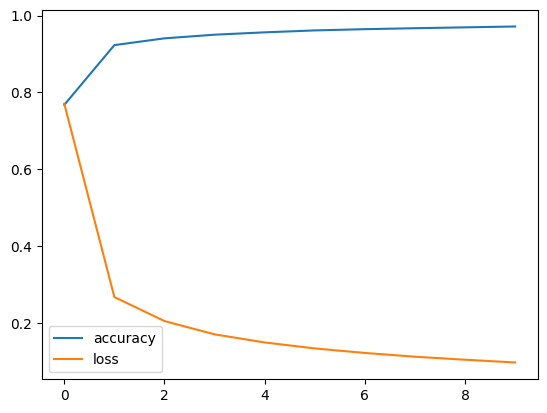

In [32]:
model_srf = model_t1_srf(5)
training_generator = data_generator_single_visual_field(
    x_train, y_train, batch_size
)
testing_generator = data_generator_single_visual_field(
    x_test, y_test, batch_size
)

model_srf.compile(
    loss="sparse_categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
)

history_model = model_srf.fit(
    training_generator,
    steps_per_epoch=len(y_train_final) // batch_size,
    epochs=epochs,
    # validation_data=testing_generator,
    # validation_steps=len(y_test_final) // batch_size,
)

model_srf.evaluate(testing_generator, steps=len(y_test_final) // batch_size)
plot_loss_accuracy(history_model)

Save trained models

In [101]:
model_name = 'model_t1_denser'

In [102]:
model_path = f'models/{model_name}_{epochs}_{batch_size}'
os.makedirs(model_path, exist_ok=True)
model.save(model_path + '/model.keras')

Training attribute lenses

In [ ]:
output_models = generate_output_models(model=model)
training_generator = None
for out_model in output_models:
    if is_double_visual_field_model(out_model):
        training_generator = data_generator_double_visual_field(
            x_train_left, x_train_right, y_train_final, batch_size
        )
        testing_generator = data_generator_double_visual_field(
            x_test_left, x_test_right, y_test_final, batch_size
        )
    else:
        training_generator = data_generator_single_visual_field(
            x_train, y_train, batch_size
        )
        testing_generator = data_generator_single_visual_field(
            x_test, y_test, batch_size
        )

    out_model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=tf.keras.optimizers.Adam(),
        metrics=["accuracy"],
    )
    out_model.fit(
        training_generator,
        steps_per_epoch=len(y_train_final) // batch_size,
        epochs=epochs,
        # validation_data=testing_generator,
        # validation_steps=len(y_test_final) // batch_size
    )

Saving attribute lenses

In [ ]:
out_models_path = model_path + '/out_models'
os.makedirs(out_models_path, exist_ok=True)
for i, out_model in enumerate(output_models):
    out_model.save(f'{out_models_path}/out_model_{i}.keras')

### Loading model

In [16]:
model_dir = 'models/model_t1_denser_50_256/'
model_path = model_dir + 'model.keras'
out_models_dir = model_dir + 'out_models/'

model = tf.keras.models.load_model(model_path)
#output_models = [tf.keras.models.load_model(out_models_dir + out_model_filename) for out_model_filename in os.listdir(out_models_dir)]

### Visualizing neural network

Chosing input for visualization

Left visual field

In [ ]:
display_n_digits(x_test, y_test, digit=4, n=3)

Right visual field

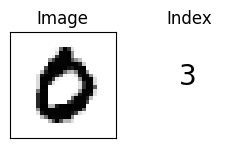

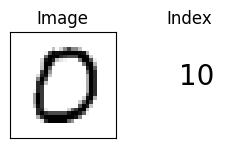

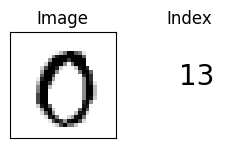

In [28]:
display_n_digits(x_test, y_test, digit=0, n=3)

## Plotting neural network

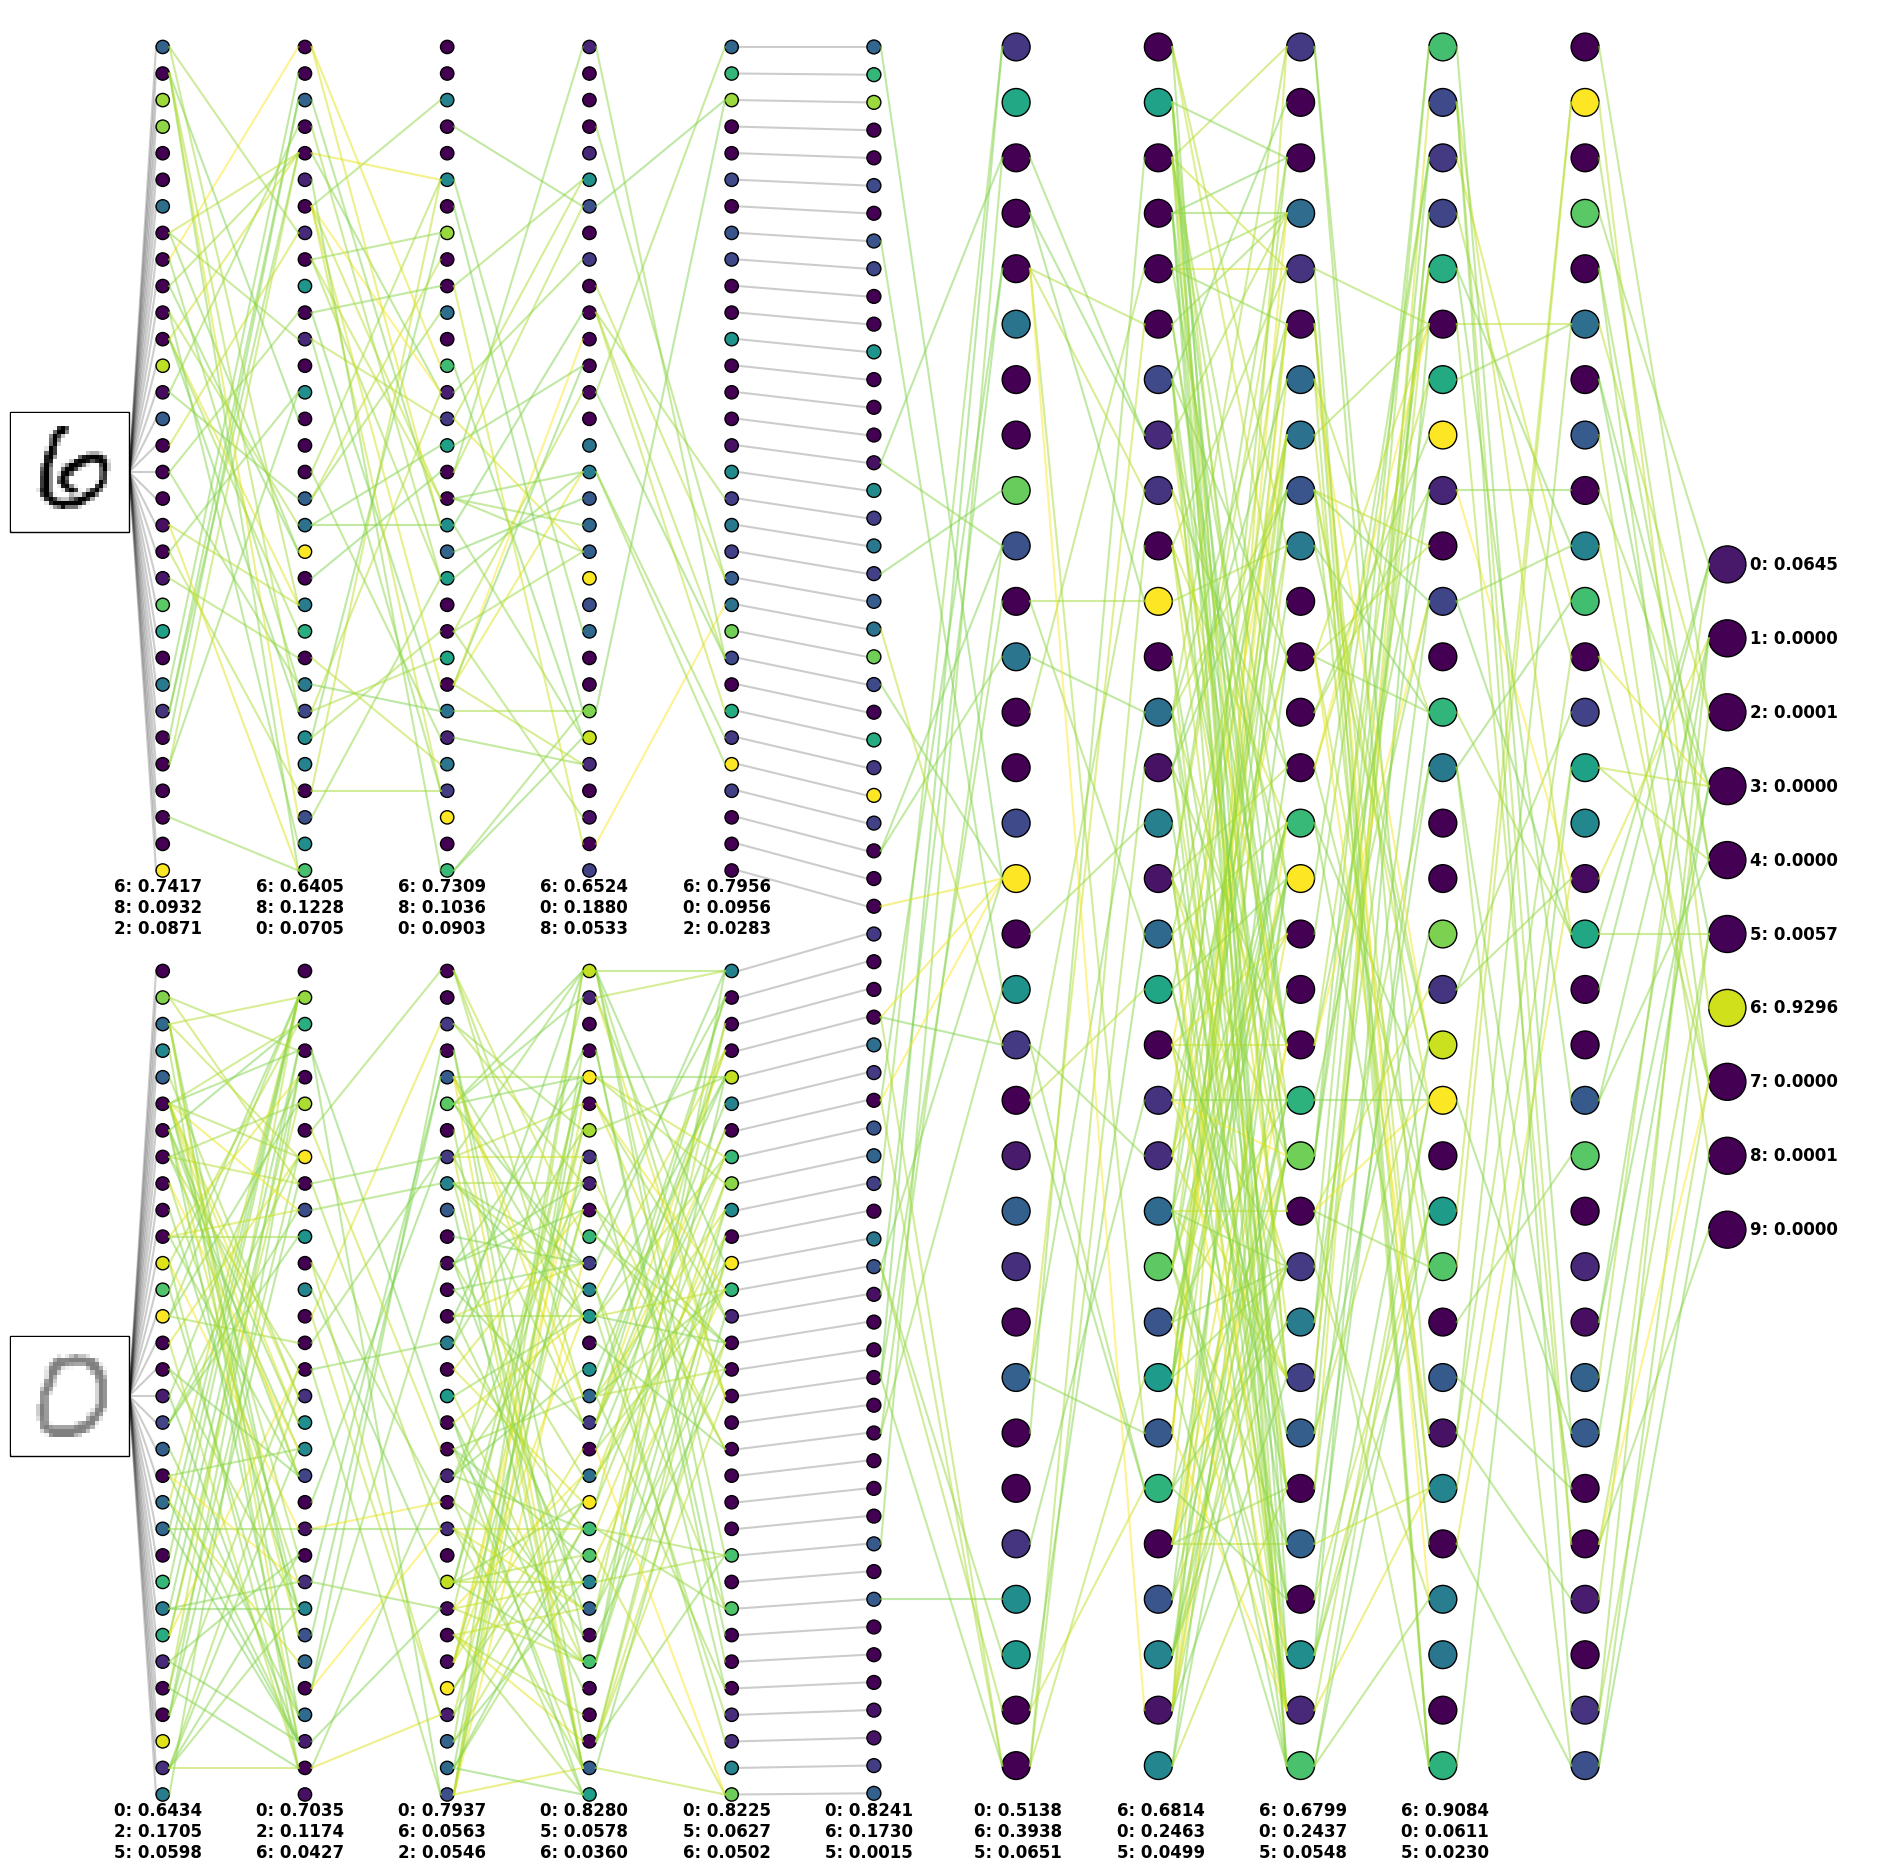

In [21]:
display_double_visual_field_mnist_nn_execution(
    model=model,
    output_models=output_models,
    k=3,
    max_neurons=600,
    weight_plot_threshold=0.8,
    data=x_test,
    left_vf_digit=(11, 1),
    right_vf_digit=(10, 0.5),
    save_image=True
)

## Metrics for Neural Network

### Cosine similarity matrix (CSM)

Generating prototypes for each digit for each layer

In [114]:
prototypes = generate_prototypes_mp(model=model, x_data=x_test, y_data=y_test, n=2)

[Cosine similarity] Starting multiprocess prototype calculation...
[Cosine similarity] Done multiprocess prototype calculation!


Computing CSM

In [119]:
cs_matrices = compute_cosine_similarity_matrix(model=model, prototypes=prototypes)

Save CSM

In [156]:
cs_matrices_path = f'results/cosine_similarity/'
cs_matrices_filename = f'{model_name}_predict_n200.csm'
cs_matrices_filepath = cs_matrices_path + cs_matrices_filename
os.makedirs(cs_matrices_path, exist_ok=True)

save_obj(cs_matrices_filepath, cs_matrices)

Load CSM

In [106]:
csm_loaded = load_obj("results/cosine_similarity/t1_drf_95/list_t1_drf_95_20.csm")[0]

Visualize CSM

In [ ]:
for layer_name in csm_loaded.keys():
    plot_csm(cs_matrices=csm_loaded, layer_name=layer_name, title=layer_name)

Plot CSM interactively

In [ ]:
plot_csm_interactively(cs_matrices=cs_matrices)

### Compute orthogonality

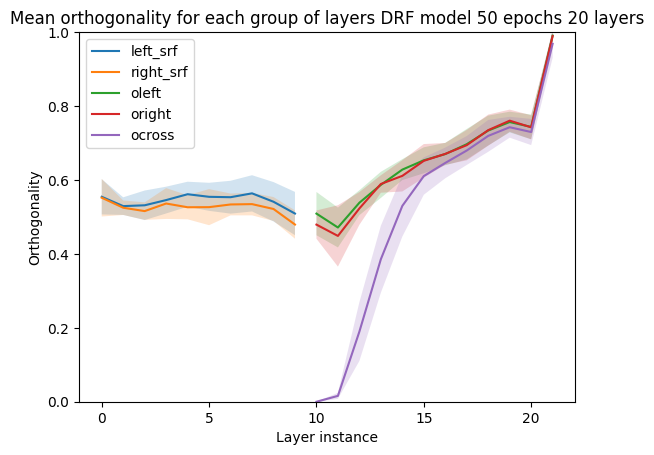

In [91]:
orthogonalities = compute_orthogonality_grouping_layers(cs_matrices=cs_matrices, separate_drf=True)
mean, deviations = compute_mean_and_deviation(orthogonalities)
plot_orthogonality(mean, deviations=deviations, label='Mean orthogonality for each group of layers DRF model 50 epochs 20 layers')

### Pipeline to train and plot orthogonality of models

In [21]:
def train_n_models(
        model_definition: Callable[[any], tf.keras.Model], 
        num_models: int, x_train: List[np.array], 
        y_train: np.array, 
        epochs: int = 50, 
        batch_size: int = 256, 
        val_split: float = 0,
        callbacks: List[tf.keras.callbacks.Callback] = [],
        model_args: List[any] = [],
        custom_dir: str = "",
        model_name: str = "",
        save: bool = True
    ) -> List[tf.keras.Model]:

    models = []

    if val_split > 0:
        x_train, x_val = split_array(x_train, val_split)
        y_train, y_val = split_array(y_train, val_split)

    if len(x_train) == 1: # If single visual field model
        data_generator = data_generator_single_visual_field
    else: # If double visual field model
        data_generator = data_generator_double_visual_field

    for _ in range(num_models):
        train_generator = data_generator(*x_train, y_train, batch_size)
        if val_split > 0:
            val_generator = data_generator(*x_val, y_val, batch_size)
        
        model = model_definition(*model_args)
        model.compile(
            loss="sparse_categorical_crossentropy",
            optimizer=tf.keras.optimizers.Adam(),
            metrics=["accuracy"],
        )

        model.fit(
            train_generator,
            steps_per_epoch=len(y_train) // batch_size,
            epochs=epochs,
            validation_data=val_generator if val_split > 0 else None,
            validation_steps=(len(y_val) // batch_size) if val_split > 0 else None,
            callbacks=callbacks
        )

        if len(callbacks) > 0:
            print(f"Model stopped training at epoch {callbacks[0].previous_epochs[-1]}")

        models.append(model)

    if len(callbacks) > 0:
        callbacks[0].epochs.append(callbacks[0].previous_epochs.copy())
        callbacks[0].previous_epochs = []
    
    if save:
        custom_dir = f"{custom_dir}/" if custom_dir != "" else ""
        model_name = f"{model_definition.__name__}_{get_current_time_string()}" if model_name == "" else model_name
        save_obj(f"models/{custom_dir}list_{model_name}", models)
    
    return models

def compute_csm_models(
        models: List[tf.keras.Model], 
        x_test: np.array, 
        y_test: np.array, 
        num_protoype: int,
        custom_dir: str = "",
        model_name: str = "",
        use_mp_protoype: bool = True,
        save: bool = True
    ) -> List[Dict[str, np.array]]:
    
    csm_list = []
    for model in models:
        if use_mp_protoype:
            prototypes = generate_prototypes_mp(model=model, x_data=x_test, y_data=y_test, n=num_protoype)
        else:
            prototypes = generate_prototypes(model=model, x_data=x_test, y_data=y_test, n=num_protoype)
        try:
            cs_matrices = compute_cosine_similarity_matrix(model=model, prototypes=prototypes)
            csm_list.append(cs_matrices)
        except ValueError as ve:
            print(f"Error caused {model.name} to be skipped: {ve}")
            continue # Skip model if it has an error
    if save:
        custom_dir = f"{custom_dir}/" if custom_dir != "" else ""
        model_name = f"model_csm_{get_current_time_string()}" if model_name == "" else model_name
        save_obj(f"results/cosine_similarity/{custom_dir}list_{model_name}.csm", csm_list)
    
    return csm_list

def compute_orthogonality_models(
        csm_list: List[Dict[str, np.array]], 
        is_srf_model: bool,
        custom_dir: str = "",
        model_name: str = "",
        separate_drf: bool = True,
        save: bool = True
    ) -> List[Dict[str, np.array]]:

    orthogonalities_list = []
    for csm in csm_list:
        orthogonalities = compute_orthogonality_grouping_layers(csm, is_srf_model=is_srf_model, separate_drf=separate_drf)
        orthogonalities_list.append(orthogonalities)
    if save:
        custom_dir = f"{custom_dir}/" if custom_dir != "" else ""
        model_name = f"model_orth_{get_current_time_string()}" if model_name == "" else model_name
        save_obj(f"results/orthogonalities/{custom_dir}list_{model_name}.orth", orthogonalities_list)

    return orthogonalities_list

def run_orthogonality_computation(
        model_definition: Callable[[any], tf.keras.Model], 
        num_models: int, 
        x_train: List[np.array], 
        y_train: np.array, 
        x_test: np.array, 
        y_test: np.array, 
        num_protoype: int,
        epochs: int = 50,
        batch_size: int = 256,
        val_split: float = 0,
        callbacks: List[tf.keras.callbacks.Callback] = [],
        model_args: List[any] = [],
        custom_dir: str = "",
        model_name: str = "",
        use_mp_protoype: bool = True,
        separate_drf: bool = True,
        save: bool = True
    ) -> Tuple[Dict[str, np.array], Dict[str, np.array]]:

    model_name = f"{model_definition.__name__}_{get_current_time_string()}" if model_name == "" else model_name

    models = train_n_models(
        model_definition=model_definition, 
        num_models=num_models, 
        x_train=x_train, 
        y_train=y_train,
        epochs=epochs,
        batch_size=batch_size,
        val_split=val_split, 
        callbacks=callbacks,
        model_args=model_args,
        custom_dir=custom_dir,
        model_name=model_name,
        save=save
    )
        
    csm_list = compute_csm_models(
        models=models, 
        x_test=x_test, 
        y_test=y_test, 
        num_protoype=num_protoype,
        custom_dir=custom_dir,
        model_name=model_name,
        use_mp_protoype=use_mp_protoype,
        save=save
    )

    orthogonalities_list = compute_orthogonality_models(
        csm_list=csm_list,
        custom_dir=custom_dir,
        model_name=model_name, 
        is_srf_model=len(x_train) == 1,
        separate_drf=separate_drf,
        save=save
    )

    mean, deviations = compute_mean_and_deviation(orthogonalities_list)
    return (mean, deviations)

Running pipeline

In [73]:
model_orth_srf = {}
max_epochs = 500
callbacks = [EpochStopping(max_epochs=max_epochs, acc_diff_threshold=0.0005, n_accs=5, max_train_acc=0.95)] # 0.99
for num_layer in [30]:# [5, 10, 15, 20, 25, 30]:
    model_orth_srf[f"{num_layer}"] = run_orthogonality_computation(
        model_definition=model_t1_srf,
        num_models=10,
        x_train=[x_train],
        y_train=y_train,
        x_test=x_test,
        y_test=y_test,
        epochs=max_epochs,
        batch_size=256,
        num_protoype=100,
        use_mp_protoype=False,
        val_split=0,
        callbacks=callbacks,
        model_args=[num_layer],
        custom_dir="t1_srf_95_100",
        model_name=f"t1_srf_95_100_{num_layer}",
        save=True
    )

Epoch 1/500
234/234 [==============================] - 4s 3ms/step - loss: 1.7315 - accuracy: 0.2677
Epoch 2/500
234/234 [==============================] - 1s 3ms/step - loss: 1.0045 - accuracy: 0.5781
Epoch 3/500
234/234 [==============================] - 1s 3ms/step - loss: 0.7471 - accuracy: 0.7398
Epoch 4/500
234/234 [==============================] - 1s 4ms/step - loss: 0.5533 - accuracy: 0.8521
Epoch 5/500
234/234 [==============================] - 1s 3ms/step - loss: 0.4813 - accuracy: 0.8823
Epoch 6/500
234/234 [==============================] - 1s 3ms/step - loss: 0.4350 - accuracy: 0.8984
Epoch 7/500
234/234 [==============================] - 1s 4ms/step - loss: 0.4180 - accuracy: 0.9025
Epoch 8/500
234/234 [==============================] - 1s 3ms/step - loss: 0.4336 - accuracy: 0.9019
Epoch 9/500
234/234 [==============================] - 1s 3ms/step - loss: 0.4486 - accuracy: 0.8926
Epoch 10/500
234/234 [==============================] - 1s 3ms/step - loss: 0.4015 - accura

Plotting orthogonalities

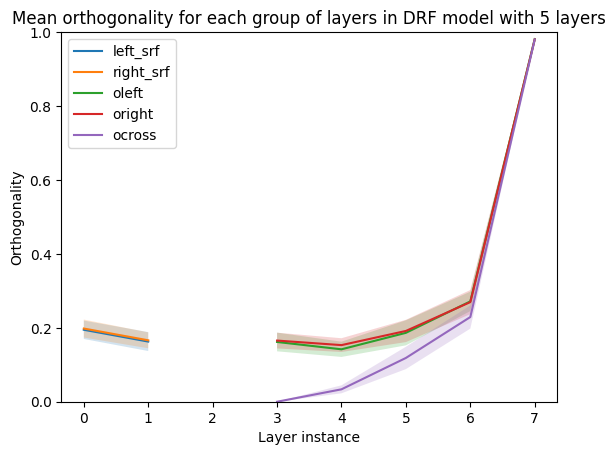

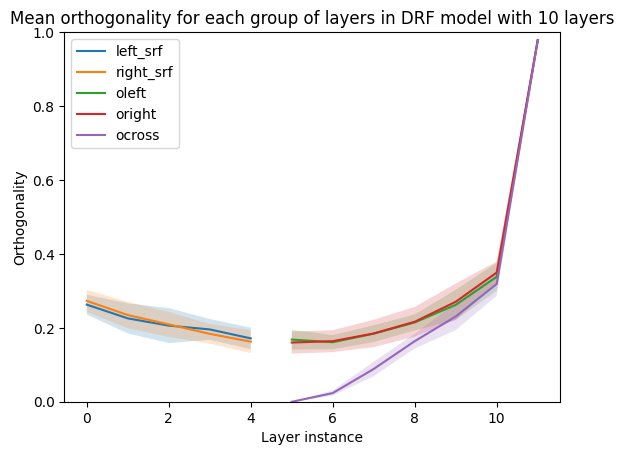

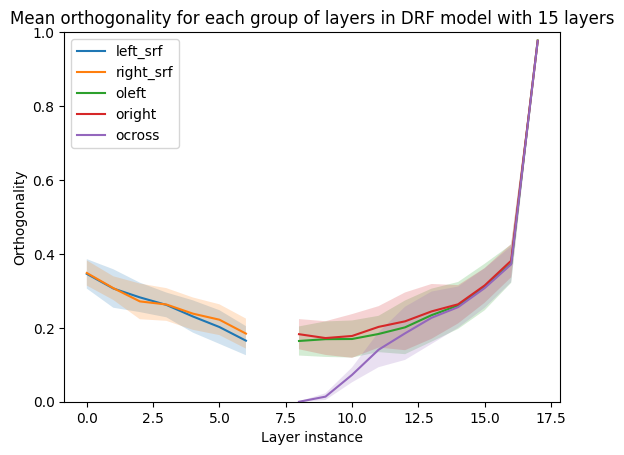

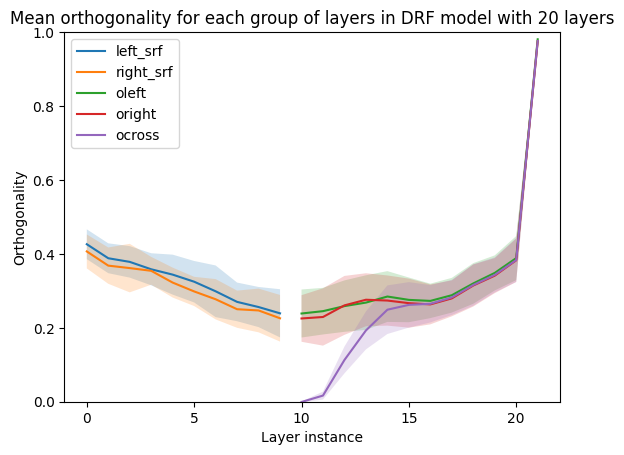

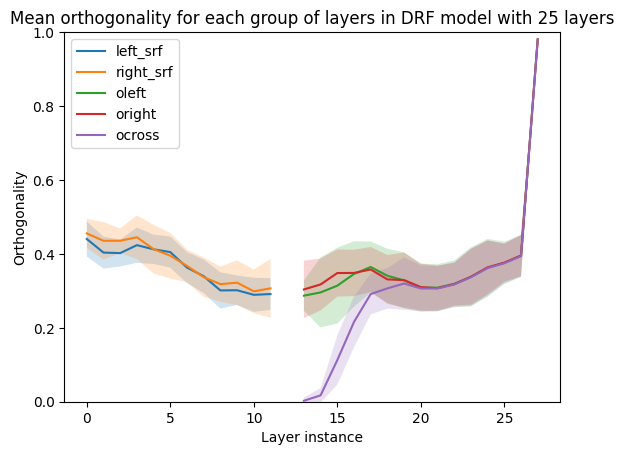

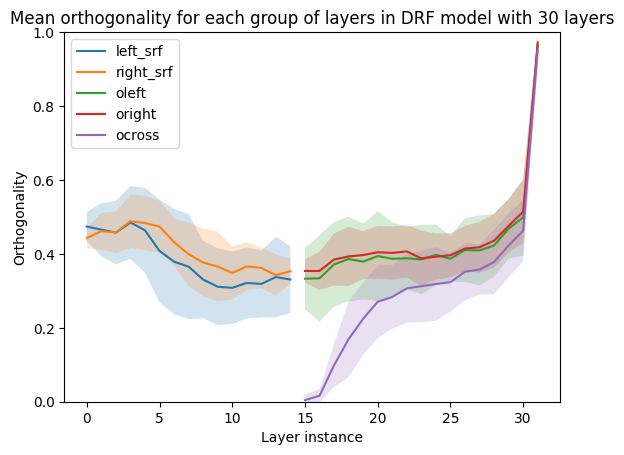

In [29]:
model_orth = model_orth_drf
for key in model_orth:
    plot_orthogonality(model_orth[key][0], deviations=model_orth[key][1], label=f'Mean orthogonality for each group of layers in DRF model with {key} layers')

Evaluating models

In [61]:
acc_mean = {}
acc_std = {}
loss_mean = {}
loss_std = {}
for key in models:
    acc_list = []
    loss_list = []
    for model in models[key]:
        loss, acc = model.evaluate([x_test_left, x_test_right], y_test_final)
        acc_list.append(acc)
        loss_list.append(loss)
    acc_mean[key] = np.mean(acc_list)
    loss_mean[key] = np.mean(loss_list)
    acc_std[key] = np.std(acc_list)
    loss_std[key] = np.std(loss_list)

x = list(acc_mean.keys())
y = list(acc_mean.values())

plt.title("Avg Accuracy vs Number of Layers for DRF Model")
plt.xlabel("Number of Layers")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1)
plt.fill_between(x, y - np.array(list(acc_std.values())), np.array(y) + np.array(list(acc_std.values())), alpha=0.2)

plt.plot(x, y)

313/313 [==============================] - 1s 2ms/step - loss: 0.3114 - accuracy: 0.9266
